In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib.cm as cm
from scipy.interpolate import PchipInterpolator

#silicon n-k data extraction
ref_silicon = r"C:\School Stuff\UC Davis\Leite Lab\Data\si.txt"

# Containers/the columns of your data
wavelength_nm_silicon= []
n_vals_si = []
k_vals_si = []

#extracts data from multiple columns 
with open(ref_silicon , "r") as f: #opens file = 'filename' in readmode --> 'r' and assigns this to a variable, f 
    header = f.readline()  # reads 'one complete HORIZONTAL line' in the file and stores that information in the'header' variable, as this is usually header information. 
    for line in f: #the first horizontal line is read, so now the file pointer is on line two. It will now to start to loop line by line. 
        if not line.strip():
            continue  # line.strip just removes any spaces, commas, etc. that are in the line, and then if the line is empty, it gets skipped over, and the next line is examined 

        wl, n, k = line.split() #the horizontal line is split into columns now, and you WILL alter this for your data file to extract column info line by line(row by row). 
        wavelength_nm_silicon.append(float(wl))
        n_vals_si.append(float(n))
        k_vals_si.append(float(k))


# Read the second file with single column
inter_range = r"C:\School Stuff\UC Davis\Leite Lab\Data\Wavelength Range for Interpolation.txt"
interpolation_range = []
with open(inter_range, "r") as f:
    header = f.readline()  # skip header line
    for line in f:
        if not line.strip():
            continue  # skip empty lines
        value = line.strip()
        interpolation_range.append(float(value))

# Converting my reference silicon data from lists --> numpy arrays so that they can be used for calculations. 
wavelengths1= np.array(wavelength_nm_silicon) 
n_data_si = np.array(n_vals_si) #n & k data of silicon 
k_data_si = np.array(k_vals_si) 

# Create the splines for fitting 
pchip_n = PchipInterpolator(wavelengths1, n_data_si)
pchip_k = PchipInterpolator(wavelengths1, k_data_si)

# Interpolate at any x values(wavelengths) within your range
wavelengths_exp = np.array(interpolation_range)  #This is the wavelength range from margaret's data 
n_new_si = pchip_n(wavelengths_exp) #this is now going to use the wavelength range as the input for the interpolation functions 
k_new_si = pchip_k(wavelengths_exp)

#extracting Margaret's experimental Data

md_data = r"C:\School Stuff\UC Davis\Leite Lab\Data\am2c14613_si_001.txt"

#initialize the lists
wl_exp = []
e1_Mo = []
e2_Mo = []
e1_Ru = []
e2_Ru = []
e1_Ta = []
e2_Ta = []
e1_W = []
e2_W = []
e1_MoO3 = []
e2_MoO3 = []
e1_RuO2 = []
e2_RuO2 = []
e1_Ta2O5 = []
e2_Ta2O5 = []
e1_WO3 = []
e2_WO3 = []

with open(md_data, 'r') as f:
    header = f.readline() #stores header information and disregards it 
    for line in f:
        if not line.strip(): #if there's nothing in the line, skip it 
            continue 

        #Split the text file into columns, the file is split by tabs, not spaces
        values = line.split('\t') #if it was split by spaces the argument would be empty 
                                  #since there are 17 columns the index goes from 0 --> 16 

        wl_exp.append(float(values[0]))
        e1_Mo.append(float(values[1]))
        e2_Mo.append(float(values[2]))
        e1_Ru.append(float(values[3]))
        e2_Ru.append(float(values[4]))
        e1_Ta.append(float(values[5]))
        e2_Ta.append(float(values[6]))
        e1_W.append(float(values[7]))
        e2_W.append(float(values[8]))
        e1_MoO3.append(float(values[9]))
        e2_MoO3.append(float(values[10]))
        e1_RuO2.append(float(values[11]))
        e2_RuO2.append(float(values[12]))
        e1_Ta2O5.append(float(values[13]))
        e2_Ta2O5.append(float(values[14]))
        e1_WO3.append(float(values[15]))
        e2_WO3.append(float(values[16]))

wl_exp_array = np.array(wl_exp)
e1_Mo_array = np.array(e1_Mo)
e2_Mo_array = np.array(e2_Mo)
e1_Ru_array = np.array(e1_Ru)
e2_Ru_array = np.array(e2_Ru)
e1_Ta_array = np.array(e1_Ta)
e2_Ta_array = np.array(e2_Ta)
e1_W_array = np.array(e1_W)
e2_W_array = np.array(e2_W)
e1_MoO3_array = np.array(e1_MoO3)
e2_MoO3_array = np.array(e2_MoO3)
e1_RuO2_array = np.array(e1_RuO2)
e2_RuO2_array = np.array(e2_RuO2)
e1_Ta2O5_array = np.array(e1_Ta2O5)
e2_Ta2O5_array = np.array(e2_Ta2O5)
e1_WO3_array = np.array(e1_WO3)
e2_WO3_array = np.array(e2_WO3)

#cutting off data for all wavelengths below 299 nm 

idx = np.argmin(np.abs(wl_exp_array - 300)) #finding the index for filtering 

wl_exp_array_filtered = wl_exp_array[idx:]
e1_Mo_array_filtered = e1_Mo_array[idx:]
e2_Mo_array_filtered = e2_Mo_array[idx:]
e1_Ru_array_filtered = e1_Ru_array[idx:]
e2_Ru_array_filtered = e2_Ru_array[idx:]
e1_Ta_array_filtered = e1_Ta_array[idx:]
e2_Ta_array_filtered = e2_Ta_array[idx:]
e1_W_array_filtered = e1_W_array[idx:]
e2_W_array_filtered = e2_W_array[idx:]
e1_MoO3_array_filtered = e1_MoO3_array[idx:]
e2_MoO3_array_filtered = e2_MoO3_array[idx:]
e1_RuO2_array_filtered = e1_RuO2_array[idx:]
e2_RuO2_array_filtered = e2_RuO2_array[idx:]
e1_Ta2O5_array_filtered = e1_Ta2O5_array[idx:]
e2_Ta2O5_array_filtered = e2_Ta2O5_array[idx:]
e1_WO3_array_filtered = e1_WO3_array[idx:]
e2_WO3_array_filtered = e2_WO3_array[idx:]

"""
plt.plot(wl_exp_array, e2_Ru_array, color = 'blue', label = 'Ru')
plt.plot(wl_exp_array, e2_Ta_array, color = 'green', label = 'Ta')
plt.plot(wl_exp_array, e2_W_array, color = 'red', label = 'W') 
plt.plot(wl_exp_array, e2_RuO2_array, color = 'blue', label = 'RuO2')
plt.plot(wl_exp_array, e2_Ta2O5_array, color = 'green', label = 'Ta2O5')
plt.plot(wl_exp_array, e2_WO3_array, color = 'red', label = 'WO3') 
plt.xticks([300, 600, 900, 1200, 1500])
plt.xlabel('Wavelength (nm)')
plt.xlim([280, 1700])
plt.ylabel(r'$\epsilon_{2}$')
plt.ylabel(r'$\epsilon_{1}$')
plt.legend()
plt.show()
"""

#Functions for calculating the real and imaginary parts of the refractive index, and then giving the total complex one. 

def refract_index_REDO(eps_real, eps_im):
    eps_complex = eps_real + 1j * eps_im
    n_complex = np.sqrt(eps_complex) 
    return n_complex 

def theta_transmit(theta_incident, n1, n2): #where n1 and n2 refer to the index of refraction of the material the light is currently in and the material the light enters, respectively. 
    return np.arcsin(n1 / n2 * np.sin(theta_incident)) #make sure that the very first theta incident is pi/2 radians, don't put in 90 because it's not in degrees

def coeffs(n_incident, n_transmit, theta_incident, theta_transmit):
    r_s = (n_incident * np.cos(theta_incident) - n_transmit * np.cos(theta_transmit)) / (n_incident * np.cos(theta_incident) + n_transmit * np.cos(theta_transmit))
    t_s = (2 * n_incident * np.cos(theta_incident)) / (n_incident * np.cos(theta_incident) + n_transmit * np.cos(theta_transmit))
    r_p = (n_transmit * np.cos(theta_incident) - n_incident * np.cos(theta_transmit)) / (n_transmit * np.cos(theta_incident) + n_incident * np.cos(theta_transmit))
    t_p = (2 * n_transmit * np.cos(theta_incident)) / (n_transmit * np.cos(theta_incident) + n_incident * np.cos(theta_transmit))
    return r_s, t_s, r_p, t_p 
    
def phi_j(lamb, n_complex, thickness, theta_incident):
    return (2 * np.pi) * (n_complex) * (thickness) * np.cos(theta_incident) / (lamb) 

def prop_matrix(phi):
    return np.array([[np.exp(-1j*phi), 0],
                     [0, np.exp(1j*phi)]])

def sp_tmatrix(t,r):
    return (1/t) * np.array([[1, r],
                             [r, 1]])

def pp_tmatrix(t,r):
    return (1/t) * np.array([[1, r],
                             [r, 1]])
    
def calc_reflectivity(M21, M11):
    return (np.abs(M21 / M11))**2

<>:153: SyntaxWarning: invalid escape sequence '\e'
<>:153: SyntaxWarning: invalid escape sequence '\e'
C:\Users\bryan\AppData\Local\Temp\ipykernel_7292\771240881.py:153: SyntaxWarning: invalid escape sequence '\e'
  plt.ylabel(r'$\epsilon_{2}$')


C:\Users\bryan\AppData\Local\Temp\ipykernel_7292\1525746576.py:87: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_rainbow')


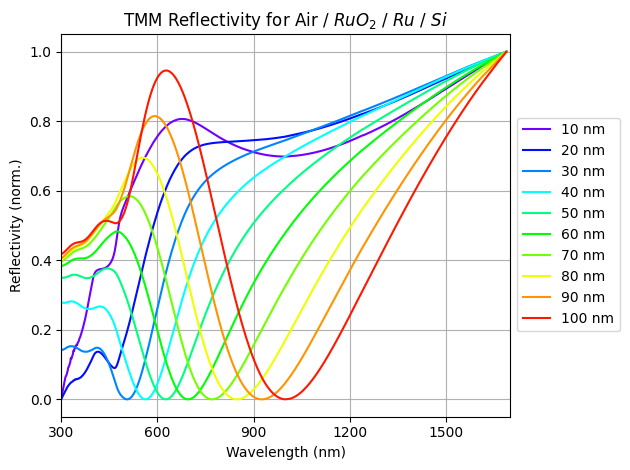

In [6]:
#going to start off by just calculating it for one wavelength, and one oxide thickness 



#initializing variables that will always be constant/need to be outside of the loop 
thick_metal = 20 #in units of nm
n_air = 1 #index of refraction of air 

#initializing the General Reflectivity array, Oxide thickness array, and Input wavelengths
thickness_oxide = np.arange(10, 110, 10) #also in units of nm, the oxide thicknesses. 

inp_wl = wl_exp_array_filtered #the wavelengths I'm going to be using for the calculations 
#inp_wl = wl_exp_array

theta_incident = (np.pi / 180) * 0 # You can either put in your incident angle directly as radians or put it in as degrees and then convert it to radians. 
reflectivity = []

#Ruthenium Calculations 
for f, thickness in enumerate(thickness_oxide):
    reflectivity_at_this_thickness = []  # New list for each thickness
    
    for i, wavelength in enumerate(inp_wl): 
        n_RuO2 = refract_index_REDO(e1_RuO2_array_filtered[i], e2_RuO2_array_filtered[i])
        n_Ru = refract_index_REDO(e1_Ru_array_filtered[i], e2_Ru_array_filtered[i]) #argument is eps_real and eps_imaginary of the dielectric function at that wavelength 

        #n_RuO2 = refract_index_REDO(e1_Ta2O5_array_filtered[i], e2_Ta2O5_array_filtered[i]) #just replace the arg
        #n_Ru = refract_index_REDO(e1_Ta_array_filtered[i], e2_Ta_array_filtered[i])

        #n_RuO2 = refract_index_REDO(e1_Ta2O5_array[i], e2_Ta2O5_array[i]) #just replace the arg  NON FILTERED
        #n_Ru = refract_index_REDO(e1_Ta_array[i], e2_Ta_array[i])

        #n_RuO2 = refract_index_REDO(e1_WO3_array_filtered[i], e2_WO3_array_filtered[i]) #just replace the arg
        #n_Ru = refract_index_REDO(e1_W_array_filtered[i], e2_W_array_filtered[i])
        
        n_si = n_new_si[i] + 1j * k_new_si[i]


        #rest of the calculations
        theta_A2O = theta_transmit(theta_incident, n_air, n_RuO2) #transmitted angle going from Air 2 Oxide (0 for NI) 
        theta_O2M  = theta_transmit(theta_A2O, n_RuO2, n_Ru) #transmitted angle going from Oxide 2 Metal (0 for NI) 
        theta_M2SIL = theta_transmit(theta_O2M, n_Ru, n_si) #these are in radians 

        r_sA2O, t_sA2O, r_pA2O, t_pA2O = coeffs(n_air, n_RuO2, theta_incident, theta_A2O)
        r_sO2M, t_sO2M, r_pO2M, t_pO2M = coeffs(n_RuO2, n_Ru, theta_A2O, theta_O2M)
        r_sM2SIL, t_sM2SIL, r_pM2SIL, t_pM2SIL = coeffs(n_Ru, n_si, theta_O2M, theta_M2SIL)

        phi_j_oxide = phi_j(wavelength, n_RuO2, thickness, theta_A2O)
        phi_j_metal = phi_j(wavelength, n_Ru, thick_metal, theta_O2M)

        p_matrix_oxide = prop_matrix(phi_j_oxide) #calculating propagation matrices 
        p_matrix_metal = prop_matrix(phi_j_metal)

        sp_tmatrix_A2O = sp_tmatrix(t_sA2O,r_sA2O)
        sp_tmatrix_O2M = sp_tmatrix(t_sO2M,r_sO2M)
        sp_tmatrix_M2SIL = sp_tmatrix(t_sM2SIL,r_sM2SIL)

        pp_tmatrix_A2O = sp_tmatrix(t_pA2O,r_pA2O)
        pp_tmatrix_O2M = sp_tmatrix(t_pO2M,r_pO2M)
        pp_tmatrix_M2SIL = sp_tmatrix(t_pM2SIL,r_pM2SIL)


        M_tot_sp = sp_tmatrix_A2O @ p_matrix_oxide @ sp_tmatrix_O2M @ p_matrix_metal @ sp_tmatrix_M2SIL
        M_tot_pp = pp_tmatrix_A2O @ p_matrix_oxide @ pp_tmatrix_O2M @ p_matrix_metal @ pp_tmatrix_M2SIL

        R_sp = calc_reflectivity(M_tot_sp[1,0], M_tot_sp[0,0])
        R_pp = calc_reflectivity(M_tot_pp[1,0], M_tot_pp[0,0])
        
        R_avg = (R_sp + R_pp) / 2 

        reflectivity_at_this_thickness.append(R_avg)

    reflectivity.append(reflectivity_at_this_thickness)

# Plotting:
cmap = cm.get_cmap('gist_rainbow')
n = len(thickness_oxide)

for i, thickness in enumerate(thickness_oxide):
    #reflectivity_normalized = np.array(reflectivity[i]) / np.max(reflectivity[i]) #my original normalization 

    #trying out 'min-max' normalization
    reflectivity_normalized = np.array( (reflectivity[i] - np.min(reflectivity[i])) / (np.max(reflectivity[i]) - np.min(reflectivity[i])) )
    color = cmap(0.85 - 0.8 * i/(n-1))
    plt.plot(inp_wl, reflectivity_normalized, label=f'{thickness} nm', color = color)
  

plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectivity (norm.)')
plt.title(r'TMM Reflectivity for Air / $RuO_{2}$ / $Ru$ / $Si$')
plt.xlim(300, 1700) # Specify both min and max
plt.xticks([300, 600, 900, 1200, 1500])
plt.legend(bbox_to_anchor=(1.00, 0.8), loc='upper left')
plt.grid(True)
plt.tight_layout() # prevents the legend from being cut off
plt.show()

C:\Users\bryan\AppData\Local\Temp\ipykernel_4272\2666587283.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_rainbow')


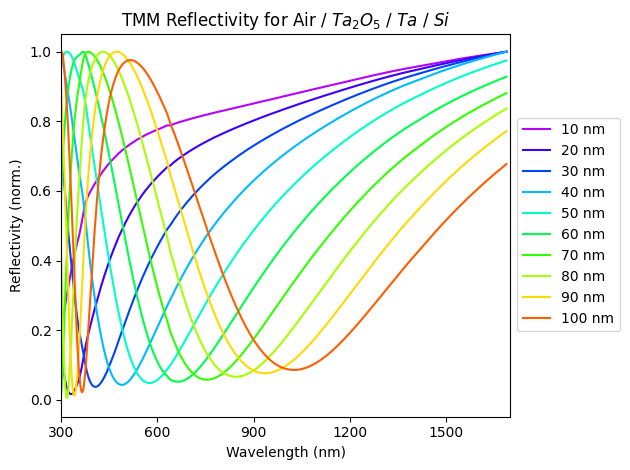

In [13]:
reflectivity_tantalum = []

for f, thickness in enumerate(thickness_oxide):
    reflectivity_at_this_thickness = []  # New list for each thickness
    
    for i, wavelength in enumerate(inp_wl): 
        n_RuO2 = refract_index_REDO(e1_Ta2O5_array[i], e2_Ta2O5_array[i]) #just replace the arg
        n_Ru = refract_index_REDO(e1_Ta_array[i], e2_Ta_array[i])
        n_si = n_new_si[i] + 1j * k_new_si[i]

        theta_A2O = theta_transmit(theta_incident, n_air, n_RuO2) #transmitted angle going from Air 2 Oxide (0 for NI) 
        theta_O2M  = theta_transmit(theta_A2O, n_RuO2, n_Ru) #transmitted angle going from Oxide 2 Metal (0 for NI) 
        theta_M2SIL = theta_transmit(theta_O2M, n_Ru, n_si)

        r_sA2O, t_sA2O, r_pA2O, t_pA2O = coeffs(n_air, n_RuO2, theta_incident, theta_A2O)
        r_sO2M, t_sO2M, r_pO2M, t_pO2M = coeffs(n_RuO2, n_Ru, theta_A2O, theta_O2M)
        r_sM2SIL, t_sM2SIL, r_pM2SIL, t_pM2SIL = coeffs(n_Ru, n_si, theta_O2M, theta_M2SIL)

        phi_j_oxide = phi_j(wavelength, n_RuO2, thickness, theta_A2O)
        phi_j_metal = phi_j(wavelength, n_Ru, thick_metal, theta_O2M)

        p_matrix_oxide = prop_matrix(phi_j_oxide) #calculating propagation matrices 
        p_matrix_metal = prop_matrix(phi_j_metal)

        sp_tmatrix_A2O = sp_tmatrix(t_sA2O,r_sA2O)
        sp_tmatrix_O2M = sp_tmatrix(t_sO2M,r_sO2M)
        sp_tmatrix_M2SIL = sp_tmatrix(t_sM2SIL,r_sM2SIL)

        pp_tmatrix_A2O = sp_tmatrix(t_pA2O,r_pA2O)
        pp_tmatrix_O2M = sp_tmatrix(t_pO2M,r_pO2M)
        pp_tmatrix_M2SIL = sp_tmatrix(t_pM2SIL,r_pM2SIL)


        M_tot_sp = sp_tmatrix_A2O @ p_matrix_oxide @ sp_tmatrix_O2M @ p_matrix_metal @ sp_tmatrix_M2SIL
        M_tot_pp = pp_tmatrix_A2O @ p_matrix_oxide @ pp_tmatrix_O2M @ p_matrix_metal @ pp_tmatrix_M2SIL

        R_sp = calc_reflectivity(M_tot_sp[1,0], M_tot_sp[0,0])
        R_pp = calc_reflectivity(M_tot_pp[1,0], M_tot_pp[0,0])

        R_avg = (R_sp + R_pp) / 2 

        reflectivity_at_this_thickness.append(R_avg)

    reflectivity_tantalum.append(reflectivity_at_this_thickness)

# Plotting:
cmap = cm.get_cmap('gist_rainbow')
n = len(thickness_oxide)

for i, thickness in enumerate(thickness_oxide):
    reflectivity_normalized = np.array(reflectivity_tantalum[i]) / np.max(reflectivity_tantalum[i])
    color = cmap(0.9 - 0.8 * i/(n-1))
    #plt.plot(inp_wl, reflectivity_tantalum[i], label=f'{thickness} nm', color = color)
    plt.plot(inp_wl, reflectivity_normalized, label=f'{thickness} nm', color = color)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectivity (norm.)')
plt.title(r'TMM Reflectivity for Air / $Ta_{2}O_{5}$ / $Ta$ / $Si$')
plt.xlim(300, 1700) # Specify both min and max
plt.xticks([300, 600, 900, 1200, 1500])
plt.legend(bbox_to_anchor=(1.00, 0.8), loc='upper left')
plt.tight_layout() # prevents the legend from being cut off
plt.show()

C:\Users\bryan\AppData\Local\Temp\ipykernel_4272\2227677756.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_rainbow')


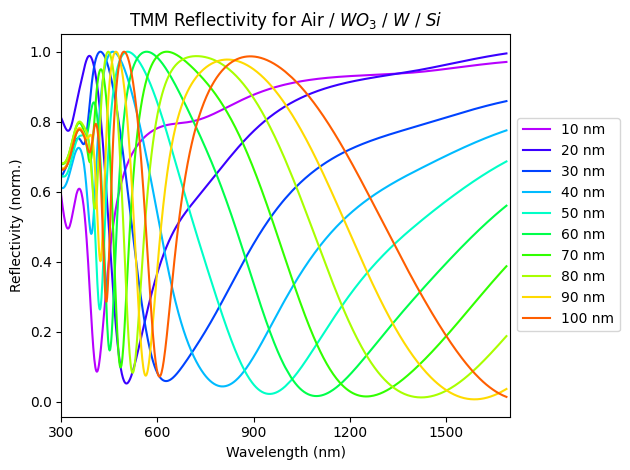

In [12]:
reflectivity_tungsten = []

for f, thickness in enumerate(thickness_oxide):
    reflectivity_at_this_thickness = []  # New list for each thickness
    
    for i, wavelength in enumerate(inp_wl): 
        n_RuO2 = refract_index_REDO(e1_WO3_array[i], e2_WO3_array[i]) #just replace the arg
        n_Ru = refract_index_REDO(e1_W_array[i], e2_W_array[i])
        n_si = n_new_si[i] + 1j * k_new_si[i]

        theta_A2O = theta_transmit(theta_incident, n_air, n_RuO2) #transmitted angle going from Air 2 Oxide (0 for NI) 
        theta_O2M  = theta_transmit(theta_A2O, n_RuO2, n_Ru) #transmitted angle going from Oxide 2 Metal (0 for NI) 
        theta_M2SIL = theta_transmit(theta_O2M, n_Ru, n_si)

        r_sA2O, t_sA2O, r_pA2O, t_pA2O = coeffs(n_air, n_RuO2, theta_incident, theta_A2O)
        r_sO2M, t_sO2M, r_pO2M, t_pO2M = coeffs(n_RuO2, n_Ru, theta_A2O, theta_O2M)
        r_sM2SIL, t_sM2SIL, r_pM2SIL, t_pM2SIL = coeffs(n_Ru, n_si, theta_O2M, theta_M2SIL)

        phi_j_oxide = phi_j(wavelength, n_RuO2, thickness, theta_A2O)
        phi_j_metal = phi_j(wavelength, n_Ru, thick_metal, theta_O2M)

        p_matrix_oxide = prop_matrix(phi_j_oxide) #calculating propagation matrices 
        p_matrix_metal = prop_matrix(phi_j_metal)

        sp_tmatrix_A2O = sp_tmatrix(t_sA2O,r_sA2O)
        sp_tmatrix_O2M = sp_tmatrix(t_sO2M,r_sO2M)
        sp_tmatrix_M2SIL = sp_tmatrix(t_sM2SIL,r_sM2SIL)

        pp_tmatrix_A2O = sp_tmatrix(t_pA2O,r_pA2O)
        pp_tmatrix_O2M = sp_tmatrix(t_pO2M,r_pO2M)
        pp_tmatrix_M2SIL = sp_tmatrix(t_pM2SIL,r_pM2SIL)


        M_tot_sp = sp_tmatrix_A2O @ p_matrix_oxide @ sp_tmatrix_O2M @ p_matrix_metal @ sp_tmatrix_M2SIL
        M_tot_pp = pp_tmatrix_A2O @ p_matrix_oxide @ pp_tmatrix_O2M @ p_matrix_metal @ pp_tmatrix_M2SIL

        R_sp = calc_reflectivity(M_tot_sp[1,0], M_tot_sp[0,0])
        R_pp = calc_reflectivity(M_tot_pp[1,0], M_tot_pp[0,0])

        R_avg = (R_sp + R_pp) / 2 

        reflectivity_at_this_thickness.append(R_avg)

    reflectivity_tungsten.append(reflectivity_at_this_thickness)

# Plotting:
cmap = cm.get_cmap('gist_rainbow')
n = len(thickness_oxide)

for i, thickness in enumerate(thickness_oxide):
    reflectivity_normalized = np.array(reflectivity_tungsten[i]) / np.max(reflectivity_tungsten[i])
    color = cmap(0.9 - 0.8 * i/(n-1))
    plt.plot(inp_wl, reflectivity_normalized, label=f'{thickness} nm', color = color)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectivity (norm.)')
plt.title(r'TMM Reflectivity for Air / $WO_{3}$ / $W$ / $Si$')
plt.xlim(300, 1700) # Specify both min and max
plt.xticks([300, 600, 900, 1200, 1500])
plt.legend(bbox_to_anchor=(1.00, 0.8), loc='upper left')
plt.tight_layout() # prevents the legend from being cut off
plt.show()

C:\Users\bryan\AppData\Local\Temp\ipykernel_4272\3935711413.py:47: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('gist_rainbow')


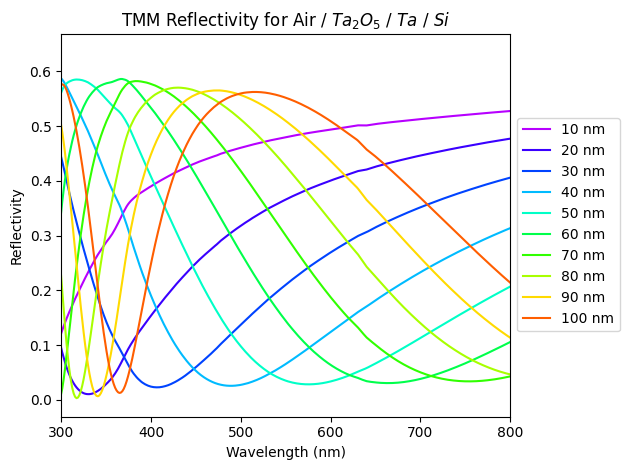

In [28]:
reflectivity_tantalum = []

for f, thickness in enumerate(thickness_oxide):
    reflectivity_at_this_thickness = []  # New list for each thickness
    
    for i, wavelength in enumerate(inp_wl): 
        n_RuO2 = refract_index_REDO(e1_Ta2O5_array[i], e2_Ta2O5_array[i]) #just replace the arg
        n_Ru = refract_index_REDO(e1_Ta_array[i], e2_Ta_array[i])
        n_si = n_new_si[i] + 1j * k_new_si[i]

        theta_A2O = theta_transmit(theta_incident, n_air, n_RuO2) #transmitted angle going from Air 2 Oxide (0 for NI) 
        theta_O2M  = theta_transmit(theta_A2O, n_RuO2, n_Ru) #transmitted angle going from Oxide 2 Metal (0 for NI) 
        theta_M2SIL = theta_transmit(theta_O2M, n_Ru, n_si)

        r_sA2O, t_sA2O, r_pA2O, t_pA2O = coeffs(n_air, n_RuO2, theta_incident, theta_A2O)
        r_sO2M, t_sO2M, r_pO2M, t_pO2M = coeffs(n_RuO2, n_Ru, theta_A2O, theta_O2M)
        r_sM2SIL, t_sM2SIL, r_pM2SIL, t_pM2SIL = coeffs(n_Ru, n_si, theta_O2M, theta_M2SIL)

        phi_j_oxide = phi_j(wavelength, n_RuO2, thickness, theta_A2O)
        phi_j_metal = phi_j(wavelength, n_Ru, thick_metal, theta_O2M)

        p_matrix_oxide = prop_matrix(phi_j_oxide) #calculating propagation matrices 
        p_matrix_metal = prop_matrix(phi_j_metal)

        sp_tmatrix_A2O = sp_tmatrix(t_sA2O,r_sA2O)
        sp_tmatrix_O2M = sp_tmatrix(t_sO2M,r_sO2M)
        sp_tmatrix_M2SIL = sp_tmatrix(t_sM2SIL,r_sM2SIL)

        pp_tmatrix_A2O = sp_tmatrix(t_pA2O,r_pA2O)
        pp_tmatrix_O2M = sp_tmatrix(t_pO2M,r_pO2M)
        pp_tmatrix_M2SIL = sp_tmatrix(t_pM2SIL,r_pM2SIL)


        M_tot_sp = sp_tmatrix_A2O @ p_matrix_oxide @ sp_tmatrix_O2M @ p_matrix_metal @ sp_tmatrix_M2SIL
        M_tot_pp = pp_tmatrix_A2O @ p_matrix_oxide @ pp_tmatrix_O2M @ p_matrix_metal @ pp_tmatrix_M2SIL

        R_sp = calc_reflectivity(M_tot_sp[1,0], M_tot_sp[0,0])
        R_pp = calc_reflectivity(M_tot_pp[1,0], M_tot_pp[0,0])

        R_avg = (R_sp + R_pp) / 2 

        reflectivity_at_this_thickness.append(R_avg)

    reflectivity_tantalum.append(reflectivity_at_this_thickness)

# Plotting:
cmap = cm.get_cmap('gist_rainbow')
n = len(thickness_oxide)

for i, thickness in enumerate(thickness_oxide):
    #reflectivity_normalized = np.array(reflectivity_tantalum[i]) / np.max(reflectivity_tantalum[i])
    color = cmap(0.9 - 0.8 * i/(n-1))
    plt.plot(inp_wl, reflectivity_tantalum[i], label=f'{thickness} nm', color = color)
    #plt.plot(inp_wl, reflectivity_normalized, label=f'{thickness} nm', color = color)

plt.xlabel('Wavelength (nm)')
plt.ylabel('Reflectivity')
plt.title(r'TMM Reflectivity for Air / $Ta_{2}O_{5}$ / $Ta$ / $Si$')
plt.xlim(300, 800) # Specify both min and max
#plt.xticks([300, 600, 900, 1200, 1500])
plt.legend(bbox_to_anchor=(1.00, 0.8), loc='upper left')
plt.tight_layout() # prevents the legend from being cut off
plt.show()